In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)

n = 150

df = pd.DataFrame({
    "OrderID": np.arange(1, n+1),
    "Product": np.random.choice(["Laptop", "Phone", "Tablet", "Headphones"], n),
    "Category": np.random.choice(["Electronics", "Accessories"], n),
    "Price": np.random.randint(1000, 50000, n),
    "Quantity": np.random.randint(1, 5, n),
    "City": np.random.choice(["Chennai", "Coimbatore", "Salem", "Madurai"], n),
    "CustomerID": np.random.randint(1000, 1100, n)
})


In [3]:
df["TotalSales"] = df["Price"] * df["Quantity"]

In [4]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   OrderID     Product     Category  Price  Quantity     City  CustomerID  \
0        1      Tablet  Electronics   8392         3  Chennai        1054   
1        2  Headphones  Electronics  47717         3  Chennai        1012   
2        3      Laptop  Electronics  22556         4  Chennai        1022   
3        4      Tablet  Electronics  39559         1  Madurai        1088   
4        5      Tablet  Electronics  27309         4  Chennai        1098   

   TotalSales  
0       25176  
1      143151  
2       90224  
3       39559  
4      109236  


In [5]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   OrderID     150 non-null    int32 
 1   Product     150 non-null    object
 2   Category    150 non-null    object
 3   Price       150 non-null    int32 
 4   Quantity    150 non-null    int32 
 5   City        150 non-null    object
 6   CustomerID  150 non-null    int32 
 7   TotalSales  150 non-null    int32 
dtypes: int32(5), object(3)
memory usage: 6.6+ KB
None


In [6]:
#DATA CLEANING
df = df.dropna()

In [7]:
#SUMMARY STATISTICS
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
          OrderID         Price    Quantity   CustomerID     TotalSales
count  150.000000    150.000000  150.000000   150.000000     150.000000
mean    75.500000  26074.920000    2.553333  1046.846667   66823.653333
std     43.445368  15312.761715    1.090143    28.921262   51319.145727
min      1.000000   1197.000000    1.000000  1000.000000    1197.000000
25%     38.250000  12186.000000    2.000000  1018.250000   23043.500000
50%     75.500000  25960.000000    2.500000  1045.500000   50732.000000
75%    112.750000  41282.750000    4.000000  1072.500000   96505.000000
max    150.000000  49404.000000    4.000000  1099.000000  192100.000000


In [8]:
top_products = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)
print("\nTop Selling Products:")
print(top_products)


Top Selling Products:
Product
Headphones    116
Tablet        100
Phone          92
Laptop         75
Name: Quantity, dtype: int32


In [9]:
#CATEGORY ANALYSIS
category_sales = df.groupby("Category")["TotalSales"].sum()
print("\nCategory Sales:")
print(category_sales)


Category Sales:
Category
Accessories    4741269
Electronics    5282279
Name: TotalSales, dtype: int32


In [11]:
#CITY ANALYSIS
city_sales = df.groupby("City")["TotalSales"].sum()
print("\nCity-wise Sales:")
print(city_sales)




City-wise Sales:
City
Chennai       3233543
Coimbatore    2220793
Madurai       2798714
Salem         1770498
Name: TotalSales, dtype: int32


In [12]:
#CUSTOMER ANALYSIS
customer_spending = df.groupby("CustomerID")["TotalSales"].sum().sort_values(ascending=False)
print("\nTop Customers:")
print(customer_spending.head())


Top Customers:
CustomerID
1018    516064
1038    409058
1074    393508
1012    354231
1060    331050
Name: TotalSales, dtype: int32


In [14]:
# NUMPY OPERATIONS
sales_array = df["TotalSales"].to_numpy()
print("\nNumPy Mean Sales:", np.mean(sales_array))
print("NumPy Total Sales:", np.sum(sales_array))


NumPy Mean Sales: 66823.65333333334
NumPy Total Sales: 10023548


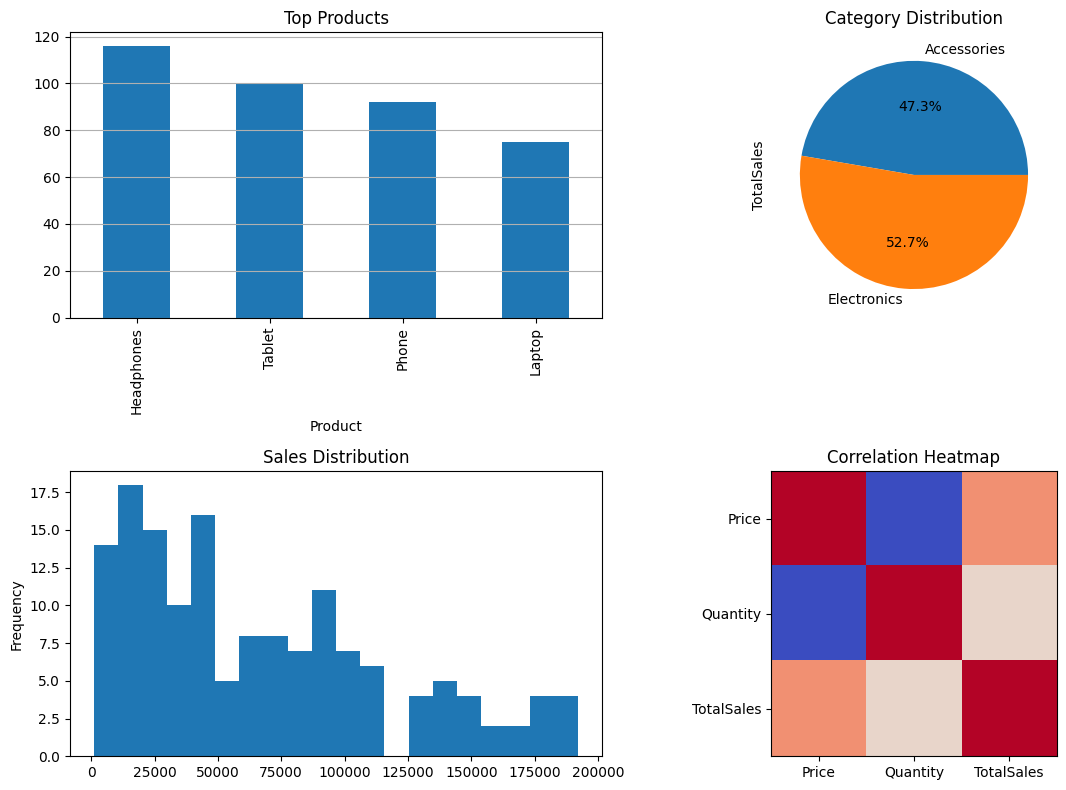

In [16]:
#VISUALIZATION

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Bar chart - Product Sales
top_products.plot(kind='bar', ax=ax[0,0], title="Top Products")
ax[0,0].grid(axis='y')

# Pie chart - Category
category_sales.plot(kind='pie', autopct='%1.1f%%', ax=ax[0,1], title="Category Distribution")

# Histogram - Sales Distribution
df["TotalSales"].plot(kind='hist', bins=20, ax=ax[1,0], title="Sales Distribution")

# Correlation Heatmap
corr = df[["Price", "Quantity", "TotalSales"]].corr()
im = ax[1,1].imshow(corr, cmap='coolwarm')
ax[1,1].set_xticks(range(3))
ax[1,1].set_yticks(range(3))
ax[1,1].set_xticklabels(["Price", "Quantity", "TotalSales"])
ax[1,1].set_yticklabels(["Price", "Quantity", "TotalSales"])
ax[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()